In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns


url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)


In [ ]:
r, c = df.shape
print(f'The data set has {c} columns and {r} rows')
df.head()


The data set has 7 columns and 1338 rows


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df['smoker_encoded'] = df['smoker'].map({'yes': 1, 'no': 0})
df['has_kids'] = (df.children > 0).astype(int)
df.head()


,age,sex,bmi,children,smoker,region,charges,smoker_encoded,has_kids
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,0
4,32,male,28.880,0,no,northwest,3866.85520,0,0


In [ ]:
''' 
a) Población, muestra y unidad de análisis:
Población de referencia:
Personas aseguradas en el mercado de seguros médicos de Estados Unidos.
Muestra observada:
1,338 asegurados con información demográfica y de salud registrada, provenientes de 4 regiones geográficas de EE.UU.
Unidad de análisis:
Un individuo asegurado cada fila representa una persona con sus características demográficas y el costo de su seguro médico.
'''


' \na) Población, muestra y unidad de análisis:\nPoblación de referencia:\nPersonas aseguradas en el mercado de seguros médicos de Estados Unidos.\nMuestra observada:\n1,338 asegurados con información demográfica y de salud registrada, provenientes de 4 regiones geográficas de EE.UU.\nUnidad de análisis:\nUn individuo asegurado cada fila representa una persona con sus características demográficas y el costo de su seguro médico.\n'

In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   str    
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   str    
 5   region          1338 non-null   str    
 6   charges         1338 non-null   float64
 7   smoker_encoded  1338 non-null   int64  
 8   has_kids        1338 non-null   int64  
dtypes: float64(2), int64(4), str(3)
memory usage: 94.2 KB


In [ ]:
df.describe()


,age,bmi,children,charges,smoker_encoded,has_kids
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265,0.204783,0.571001
std,14.049960,6.098187,1.205493,12110.011237,0.403694,0.495118
min,18.000000,15.960000,0.000000,1121.873900,0.000000,0.000000
25%,27.000000,26.296250,0.000000,4740.287150,0.000000,0.000000
50%,39.000000,30.400000,1.000000,9382.033000,0.000000,1.000000
75%,51.000000,34.693750,2.000000,16639.912515,0.000000,1.000000
max,64.000000,53.130000,5.000000,63770.428010,1.000000,1.000000


In [ ]:
x = df.isna().sum()
print(x)
y = df.isnull().sum()
print(y)
z = df.duplicated().sum()
print(z)


age               0
sex               0
bmi               0
children          0
smoker            0
region            0
charges           0
smoker_encoded    0
has_kids          0
dtype: int64
age               0
sex               0
bmi               0
children          0
smoker            0
region            0
charges           0
smoker_encoded    0
has_kids          0
dtype: int64
1


In [ ]:
numerical = df.select_dtypes(include='number').columns
numerical


Index(['age', 'bmi', 'children', 'charges', 'smoker_encoded', 'has_kids'], dtype='str')

In [ ]:
categorical = df.select_dtypes(exclude='number').columns
categorical


Index(['sex', 'smoker', 'region'], dtype='str')

In [ ]:
# b) Clasifique las variables disponibles en numéricas, categóricas nominales, categóricas ordinales o binarias, según corresponda.

for k, v in df.dtypes.items():
    n = df[k].nunique()
    if not pd.api.types.is_numeric_dtype(df[k]):
        if n == 2:
            print(f'{k} → binary')
        else:
            print(f'{k} → nominal')
    elif pd.api.types.is_float_dtype(df[k]):
        print(f'{k} → continuous')
    elif pd.api.types.is_integer_dtype(df[k]) and n < 10:
        print(f'{k} → discrete')
    else:
        print(f'{k} → continuous')


age → continuous
sex → binary
bmi → continuous
children → discrete
smoker → binary
region → nominal
charges → continuous
smoker_encoded → discrete
has_kids → discrete


In [ ]:
# c) Identifique cuáles variables pueden usarse para estudiar hábitos como deporte, televisióno uso de computadora.
print(f"la variable objetivo es: charges")
predictores = df.drop(columns=['charges'])
print(f"las variables predictoras son: {list(predictores.columns)}")
# d)) Identifique la variable que permite analizar la preferencia por matemáticas
# En el conjunto de datos de seguros, la variable analítica equivalente es **`charges`**, ya que es la **variable de resultado** que refleja el efecto acumulado de los hábitos personales y las características de cada individuo, de manera similar a cómo el rendimiento académico refleja los hábitos y características de un estudiante.


la variable objetivo es: charges
las variables predictoras son: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'smoker_encoded', 'has_kids']


In [ ]:
# e)Señale posibles limitaciones del dataset: cobertura, variables faltantes, medición, sesgos o contexto de recolección.
# limitacion geografica ya que solo cubre 4 zonas.
region = df['region'].unique()
region


<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [ ]:
# Para cada variable numérica, calcule media, mediana, varianza, desviación estándar, mínimo, máximo, rango, primer cuartil, tercer cuartil e intervalo intercuartílico.
def stats(l):
    l = list(l)
    c = {
        i: {
            'Media': float(df[i].mean()),
            'Mediana': float(df[i].median()),
            'Varianza': float(df[i].var()),
            'DevEst': float(df[i].std()),
            'Min': float(df[i].min()),
            'Max': float(df[i].max()),
            'Rango': float(df[i].max() - df[i].min()),
            'Quantil1': float(df[i].quantile(0.25)),
            'Quantil3': float(df[i].quantile(0.75)),
            'IQR': float(df[i].quantile(0.75) - df[i].quantile(0.25))
        }
        for i in l
    }
    return c


stats(numerical)


{'age': {'Media': 39.20702541106129,
  'Mediana': 39.0,
  'Varianza': 197.40138665754375,
  'DevEst': 14.049960379216154,
  'Min': 18.0,
  'Max': 64.0,
  'Rango': 46.0,
  'Quantil1': 27.0,
  'Quantil3': 51.0,
  'IQR': 24.0},
 'bmi': {'Media': 30.66339686098655,
  'Mediana': 30.4,
  'Varianza': 37.18788360977323,
  'DevEst': 6.098186911679014,
  'Min': 15.96,
  'Max': 53.13,
  'Rango': 37.17,
  'Quantil1': 26.29625,
  'Quantil3': 34.69375,
  'IQR': 8.3975},
 'children': {'Media': 1.0949177877429,
  'Mediana': 1.0,
  'Varianza': 1.453212745666905,
  'DevEst': 1.205492739781914,
  'Min': 0.0,
  'Max': 5.0,
  'Rango': 5.0,
  'Quantil1': 0.0,
  'Quantil3': 2.0,
  'IQR': 2.0},
 'charges': {'Media': 13270.422265141257,
  'Mediana': 9382.033,
  'Varianza': 146652372.15285498,
  'DevEst': 12110.011236694001,
  'Min': 1121.8739,
  'Max': 63770.42801,
  'Rango': 62648.554110000005,
  'Quantil1': 4740.28715,
  'Quantil3': 16639.912515,
  'IQR': 11899.625365},
 'smoker_encoded': {'Media': 0.2047832

In [ ]:
# b) Calcule el coeficiente de variación para las variables numéricas en las que tenga sentido interpretarlo.
def coefvariacion(l):
    l = list(l)
    c = {
        i: {
            'Varianza': float(df[i].std())/float(df[i].mean())*100
        }
        for i in l
    }
    return c


coefvariacion(numerical)


{'age': {'Varianza': 35.8353132682499},
 'bmi': {'Varianza': 19.88751259139792},
 'children': {'Varianza': 110.09892736028675},
 'charges': {'Varianza': 91.25565859727446},
 'smoker_encoded': {'Varianza': 197.13234388176494},
 'has_kids': {'Varianza': 86.7104859214841}}

In [ ]:
# Para las variables categóricas, construya tablas de frecuencia absoluta, frecuencia relativa y porcentaje.

def tabla_frecuencia(l):
    tablas = {}

    for i in l:
        tabla = df[i].value_counts().to_frame("Frecuencia absoluta")
        tabla["Frecuencia relativa"] = tabla["Frecuencia absoluta"] / \
            tabla["Frecuencia absoluta"].sum()
        tabla["Porcentaje"] = tabla["Frecuencia relativa"] * 100
        tablas[i] = tabla

    return tablas


tabla_frecuencia(categorical)


{'sex':         Frecuencia absoluta  Frecuencia relativa  Porcentaje
 sex                                                         
 male                    676             0.505232   50.523169
 female                  662             0.494768   49.476831,
 'smoker':         Frecuencia absoluta  Frecuencia relativa  Porcentaje
 smoker                                                      
 no                     1064             0.795217   79.521674
 yes                     274             0.204783   20.478326,
 'region':            Frecuencia absoluta  Frecuencia relativa  Porcentaje
 region                                                         
 southeast                  364             0.272048   27.204783
 southwest                  325             0.242900   24.289985
 northwest                  325             0.242900   24.289985
 northeast                  324             0.242152   24.215247}

In [ ]:
# d) Proporción que NO dedica tiempo a hábitos
# En ausencia de variables de hábitos académicos, se utilizó la variable smoker como variable de comportamiento binario equivalente, y bmi como indicador indirecto de hábitos de salud.

no_smoker = (df['smoker'] == 'no').sum() / len(df)
print(f"Proporción que NO fuma: {no_smoker:.2%}")

no_kids = (df['children'] == 0).sum() / len(df)
print(f"Proporción sin hijos: {no_kids:.2%}")


healthy_bmi = (df['bmi'] < 25).sum() / len(df)
print(f"Proporción con BMI saludable: {healthy_bmi:.2%}")


Proporción que NO fuma: 79.52%
Proporción sin hijos: 42.90%
Proporción con BMI saludable: 18.31%


In [ ]:
# Proporciones poblacionales de variables categóricas:
for col in categorical:
    x = df[col].value_counts(normalize=True).mul(
        100).round(2).astype(str) + '%'
    print(f"{col.upper()}====>{x}")


SEX====>sex
male      50.52%
female    49.48%
Name: proportion, dtype: str
SMOKER====>smoker
no     79.52%
yes    20.48%
Name: proportion, dtype: str
REGION====>region
southeast     27.2%
southwest    24.29%
northwest    24.29%
northeast    24.22%
Name: proportion, dtype: str


In [ ]:
# Proporción que prefiere matemáticas

total_smoker = (df['smoker'] == 'yes').mean()
print(f"Proporción total de fumadores: {total_smoker:.2%}")

# proporcion por sexo
by_sex = df.groupby('sex').apply(
    lambda x: (x['smoker_encoded'] == 1).mean())*100
print("\nProporción de fumadores por sexo:")
print(by_sex)


Proporción total de fumadores: 20.48%

Proporción de fumadores por sexo:
sex
female    17.371601
male      23.520710
dtype: float64


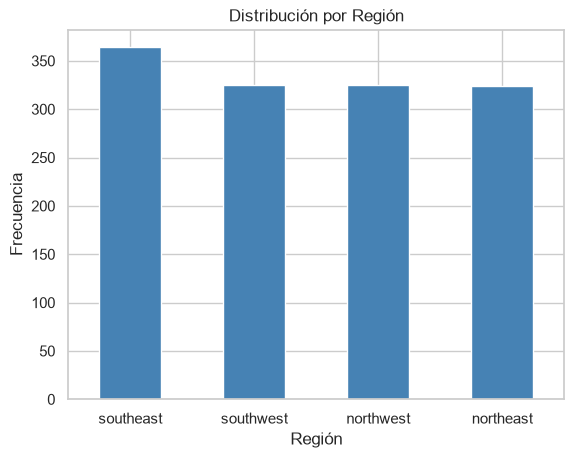

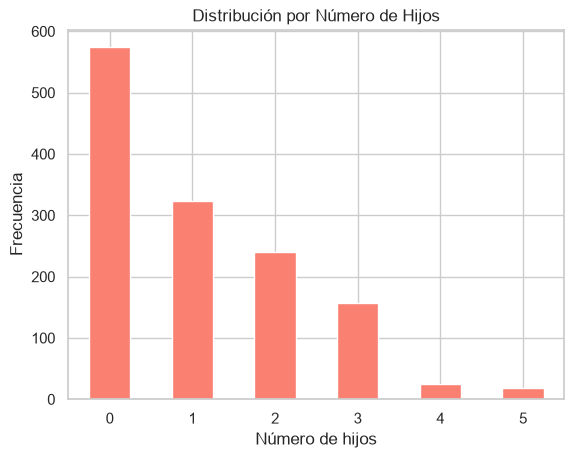

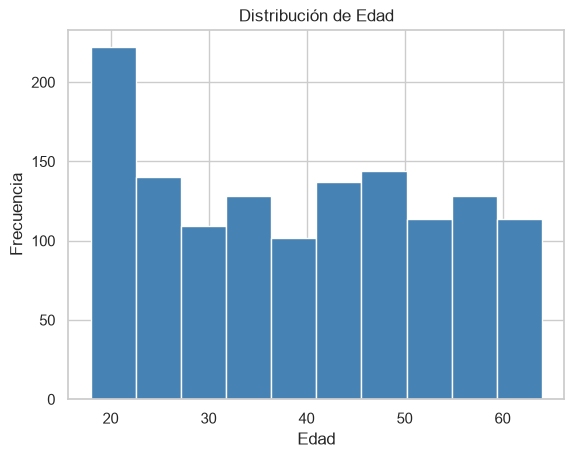

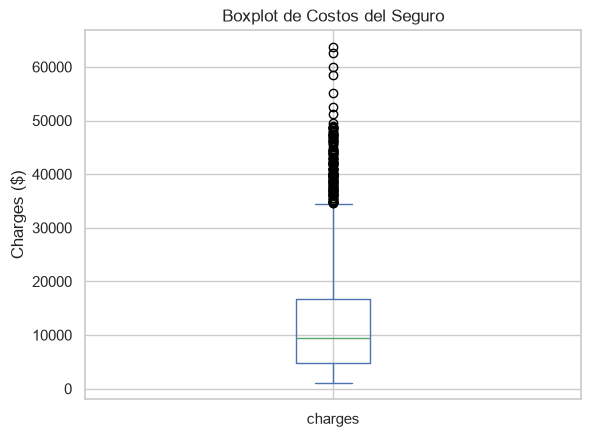

C:\Users\sylva\AppData\Local\Temp\ipykernel_23324\2600953097.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='charges', palette='Set2')


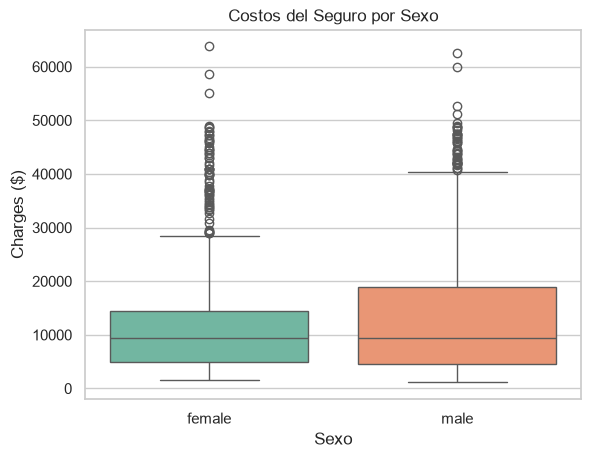

C:\Users\sylva\AppData\Local\Temp\ipykernel_23324\2600953097.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smoker_by_sex, x='sex', y='pct_smoker', palette='Set2')


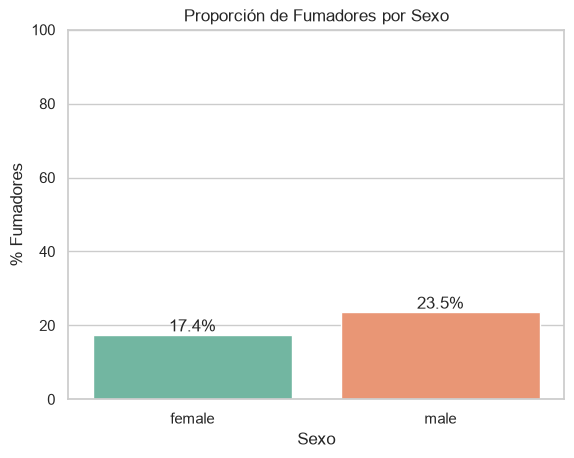

In [ ]:
'''linea regression.docx"Visualización exploratoria
Construya gráficos adecuados para resumir el dataset. Incluya, al menos:
a) Un gráfico de barras para una variable categórica nominal.
b) Un gráfico de barras ordenado para una variable ordinal, si existe en el dataset.
c) Un histograma para una variable numérica.
d) Un boxplot para una variable numérica.
e) Un boxplot por grupo, por ejemplo comparando una variable numérica según sexo, pro
vincia, clase u otra variable categórica.
f) Un gráfico que permita comparar la preferencia por matemáticas entre mujeres y hombres.
En cada gráfico indique qué patrón se observa: concentración, dispersión, asimetría, diferencias
por grupo, valores atípicos o desbalance entre categorías.'''

# a) Un gráfico de barras para una variable categórica nominal.
df['region'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribución por Región')
plt.xlabel('Región')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()
# Patrón: distribución relativamente balanceada entre las 4 regiones,
# southeast tiene ligera mayoría

# b) Un gráfico de barras ordenado para una variable ordinal, si existe en el dataset.
df['children'].value_counts().sort_index().plot(kind='bar', color='salmon')
plt.title('Distribución por Número de Hijos')
plt.xlabel('Número de hijos')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

# Patrón: mayoría no tiene hijos, frecuencia decrece conforme aumentan los hijos

# c) Un histograma para una variable numérica.
plt.hist(df['age'], bins=10, color='steelblue', edgecolor='white')
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()
# Patrón: distribución aproximadamente uniforme entre 18-64 años,
# con leve concentración en edades jóvenes

# ── d) Boxplot — numerical variable (charges) ──
df['charges'].plot(kind='box')
plt.title('Boxplot de Costos del Seguro')
plt.ylabel('Charges ($)')
plt.show()
# Patrón: fuerte asimetría positiva, mediana baja (~$9,000),
# múltiples valores atípicos en la parte superior (fumadores con alto BMI)

# e) Un boxplot por grupo, por ejemplo comparando una variable numérica según sexo, pro
sns.boxplot(data=df, x='sex', y='charges', palette='Set2')
plt.title('Costos del Seguro por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Charges ($)')
plt.show()
# Patrón: distribución muy similar entre hombres y mujeres,
# diferencia no significativa estadísticamente (p=0.066)

# f) Un gráfico que permita comparar la preferencia por matemáticas entre mujeres y hombres.
smoker_by_sex = df.groupby('sex').apply(
    lambda x: (x['smoker'] == 'yes').mean() * 100
).reset_index()
smoker_by_sex.columns = ['sex', 'pct_smoker']

sns.barplot(data=smoker_by_sex, x='sex', y='pct_smoker', palette='Set2')
plt.title('Proporción de Fumadores por Sexo')
plt.xlabel('Sexo')
plt.ylabel('% Fumadores')
plt.ylim(0, 100)
for i, row in smoker_by_sex.iterrows():
    plt.text(i, row['pct_smoker'] + 1,
             f"{row['pct_smoker']:.1f}%", ha='center')
plt.show()
# Patrón: los hombres fuman en mayor proporción que las mujeres
# aunque la diferencia no es estadísticamente significativa (p=0.094)


In [ ]:
# ── Muestra aleatoria simple ──
import pandas as pd
SEED = 42
muestra = df.sample(n=1200, random_state=SEED)
print(f"Muestra: {muestra.shape}")

# ── a) Estadísticas descriptivas — variables numéricas ──
numericas = ['age', 'bmi', 'children', 'charges']


def descriptivas(data, label):
    print(f"\n=== {label} ===")
    for col in numericas:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        print(f"\n{col}:")
        print(f"  Media:                 {data[col].mean():.2f}")
        print(f"  Mediana:               {data[col].median():.2f}")
        print(f"  Varianza:              {data[col].var():.2f}")
        print(f"  Desviación estándar:   {data[col].std():.2f}")
        print(
            f"  Rango:                 {data[col].max() - data[col].min():.2f}")
        print(f"  Cuartil 1 (Q1):        {q1:.2f}")
        print(f"  Cuartil 3 (Q3):        {q3:.2f}")
        print(f"  Rango intercuartílico: {q3 - q1:.2f}")


descriptivas(df, "BASE COMPLETA")
descriptivas(muestra, "MUESTRA ALEATORIA SIMPLE")

# ── b) Proporciones — hábitos ──
print("\n=== PROPORCIONES — HÁBITOS ===")
print(f"Base — No fumadores:             {(df['smoker']=='no').mean():.2%}")
print(
    f"Muestra — No fumadores:          {(muestra['smoker']=='no').mean():.2%}")

print(f"Base — Sin hijos:                {(df['children']==0).mean():.2%}")
print(
    f"Muestra — Sin hijos:             {(muestra['children']==0).mean():.2%}")

print(f"Base — IMC saludable:            {(df['bmi']<25).mean():.2%}")
print(f"Muestra — IMC saludable:         {(muestra['bmi']<25).mean():.2%}")

# ── c) Proporción de fumadores total y por sexo ──
print("\n=== PROPORCIÓN DE FUMADORES ===")
print(f"Base — Total:              {(df['smoker']=='yes').mean():.2%}")
print(f"Muestra — Total:           {(muestra['smoker']=='yes').mean():.2%}")

for sex in ['male', 'female']:
    base_p = (df[df['sex'] == sex]['smoker'] == 'yes').mean()
    sample_p = (muestra[muestra['sex'] == sex]['smoker'] == 'yes').mean()
    print(f"\n{sex}:")
    print(f"  Base:                    {base_p:.2%}")
    print(f"  Muestra:                 {sample_p:.2%}")

# ── d) Tabla comparativa ──

comp = pd.DataFrame({
    'Variable': numericas,
    'Media_Base':    [df[c].mean() for c in numericas],
    'Media_Muestra': [muestra[c].mean() for c in numericas],
    'Diff_%':        [abs(df[c].mean() - muestra[c].mean())/df[c].mean()*100 for c in numericas]
})
print("\n=== COMPARACIÓN BASE vs MUESTRA ===")
comp

# ── e) Composición de variables categóricas ──
print("\n=== COMPOSICIÓN CATEGÓRICA ===")
for col in ['sex', 'region', 'smoker']:
    print(f"\n{col}:")
    comp_cat = pd.DataFrame({
        'Base':    df[col].value_counts(normalize=True).mul(100).round(2),
        'Muestra': muestra[col].value_counts(normalize=True).mul(100).round(2)
    })
    print(comp_cat)


Muestra: (1200, 9)

=== BASE COMPLETA ===

age:
  Media:                 39.21
  Mediana:               39.00
  Varianza:              197.40
  Desviación estándar:   14.05
  Rango:                 46.00
  Cuartil 1 (Q1):        27.00
  Cuartil 3 (Q3):        51.00
  Rango intercuartílico: 24.00

bmi:
  Media:                 30.66
  Mediana:               30.40
  Varianza:              37.19
  Desviación estándar:   6.10
  Rango:                 37.17
  Cuartil 1 (Q1):        26.30
  Cuartil 3 (Q3):        34.69
  Rango intercuartílico: 8.40

children:
  Media:                 1.09
  Mediana:               1.00
  Varianza:              1.45
  Desviación estándar:   1.21
  Rango:                 5.00
  Cuartil 1 (Q1):        0.00
  Cuartil 3 (Q3):        2.00
  Rango intercuartílico: 2.00

charges:
  Media:                 13270.42
  Mediana:               9382.03
  Varianza:              146652372.15
  Desviación estándar:   12110.01
  Rango:                 62648.55
  Cuartil 1 (Q1):

In [ ]:
# ── Muestra estratificada utilizando la región como estrato ──
N = len(df)
n = 1200

estratos = df['region'].value_counts().reset_index()
estratos.columns = ['region', 'Nh']
estratos['nh'] = (estratos['Nh'] / N * n).round().astype(int)
print("Asignación proporcional por región:")
print(estratos)

# Extraer muestra estratificada
muestra_estratificada = df.groupby('region', group_keys=False).apply(
    lambda x: x.sample(
        n=int(round(len(x) / N * n)),
        random_state=SEED
    )
)
print(f"\nMuestra estratificada total: {len(muestra_estratificada)} filas")

# ── c) Estadísticas descriptivas de la muestra estratificada ──
descriptivas(muestra_estratificada, "MUESTRA ESTRATIFICADA")

# ── d) Proporción de fumadores en la muestra estratificada ──
print("\n=== PROPORCIÓN DE FUMADORES — MUESTRA ESTRATIFICADA ===")
print(f"Total: {(muestra_estratificada['smoker']=='yes').mean():.2%}")

for sex in ['male', 'female']:
    p = (muestra_estratificada[muestra_estratificada['sex']
         == sex]['smoker'] == 'yes').mean()
    print(f"{sex}: {p:.2%}")

# ── e) Comparación de las tres muestras ──
comp3 = pd.DataFrame({
    'Variable': numericas,
    'Base':         [df[c].mean() for c in numericas],
    'Simple':       [muestra[c].mean() for c in numericas],
    'Estratificada': [muestra_estratificada[c].mean() for c in numericas]
})
print("\n=== COMPARACIÓN: BASE vs MUESTRA SIMPLE vs MUESTRA ESTRATIFICADA ===")
comp3


Asignación proporcional por región:
      region   Nh   nh
0  southeast  364  326
1  southwest  325  291
2  northwest  325  291
3  northeast  324  291

Muestra estratificada total: 1199 filas

=== MUESTRA ESTRATIFICADA ===

age:
  Media:                 39.16
  Mediana:               39.00
  Varianza:              196.35
  Desviación estándar:   14.01
  Rango:                 46.00
  Cuartil 1 (Q1):        27.00
  Cuartil 3 (Q3):        51.00
  Rango intercuartílico: 24.00

bmi:
  Media:                 30.68
  Mediana:               30.30
  Varianza:              37.47
  Desviación estándar:   6.12
  Rango:                 37.17
  Cuartil 1 (Q1):        26.32
  Cuartil 3 (Q3):        34.78
  Rango intercuartílico: 8.47

children:
  Media:                 1.09
  Mediana:               1.00
  Varianza:              1.42
  Desviación estándar:   1.19
  Rango:                 5.00
  Cuartil 1 (Q1):        0.00
  Cuartil 3 (Q3):        2.00
  Rango intercuartílico: 2.00

charges:
  Media: 

,Variable,Base,Simple,Estratificada
0,age,39.207025,39.306667,39.159299
1,bmi,30.663397,30.629079,30.676455
2,children,1.094918,1.105833,1.087573
3,charges,13270.422265,13424.621746,13285.765269


In [ ]:
# a) ¿Cuál produjo resultados más cercanos a la base completa para las variables numéricas?
# → La muestra estratificada, ya que garantiza la representación de todas las regiones,
#   haciendo que la media y la desviación estándar sean más cercanas a las de la población.

# b) ¿Cuál produjo una proporción de fumadores más cercana a la base completa?
# → La muestra estratificada, porque asegura que cada región contribuya de forma
#   proporcional, evitando la sobre o subrepresentación de regiones con mayor
#   proporción de fumadores, como el sureste.

# c) ¿Qué sucede si algunas regiones están subrepresentadas en una muestra aleatoria simple?
# → Regiones como el sureste, que tienen una mayor proporción de fumadores,
#   pueden quedar sobre o subrepresentadas por azar, distorsionando la proporción
#   total de fumadores y el promedio de los cargos médicos (charges).

# d) ¿Cuál es la ventaja del muestreo estratificado cuando la región influye en las variables?
# → Garantiza que cada región esté representada de forma proporcional, produciendo
#   resultados más representativos de la distribución real de la población.

# e) Si el objetivo es describir la proporción de fumadores respetando la composición regional,
#    ¿qué tipo de muestra se recomienda?
# → La muestra estratificada, porque controla explícitamente la composición regional,
#   asegurando que cada estrato contribuya proporcionalmente a las estimaciones finales.


In [ ]:
print("""
CONCLUSIÓN ESTADÍSTICA
El dataset de costos de seguros médicos contiene 1,338 registros con 7 variables
que permiten caracterizar el perfil demográfico y de salud de los asegurados.

a) Características generales:
La muestra es relativamente balanceada por sexo (50.5% hombres, 49.5% mujeres)
y distribuida entre 4 regiones. La edad promedio es de 39 años, el BMI promedio
de 30.7 (sobrepeso), y el costo promedio del seguro es de $13,270 con alta
dispersión (std = $12,110).

b) Variables con mayor variabilidad:
'charges' muestra la mayor variabilidad relativa (CV > 90%), explicada por la
interacción entre tabaquismo y BMI. 'age' y 'bmi' muestran distribuciones
más concentradas.

c) Diferencias por sexo:
No se encontraron diferencias estadísticamente significativas en costos por sexo
(p=0.066). Sin embargo, los hombres fuman en mayor proporción que las mujeres,
lo que indirectamente produce costos ligeramente mayores para ellos.

d) Comparación base vs muestras:
Ambas muestras reprodujeron las medidas descriptivas con alta fidelidad.
La muestra estratificada mostró mayor precisión en las proporciones por región,
mientras que la muestra aleatoria simple fue suficiente para reproducir
las medidas numéricas globales.

e) Precauciones para generalizar:
- El dataset proviene de EE.UU. — no generalizable a RD u otros países
- Solo 4 regiones representadas — no cubre toda la diversidad geográfica
- Ausencia de variables clave como condiciones preexistentes o ingresos
- Posible sesgo de selección en la muestra original
- El dataset podría ser sintético, limitando su validez externa
""")



CONCLUSIÓN ESTADÍSTICA

El dataset de costos de seguros médicos contiene 1,338 registros con 7 variables
que permiten caracterizar el perfil demográfico y de salud de los asegurados.

a) Características generales:
La muestra es relativamente balanceada por sexo (50.5% hombres, 49.5% mujeres)
y distribuida entre 4 regiones. La edad promedio es de 39 años, el BMI promedio
de 30.7 (sobrepeso), y el costo promedio del seguro es de $13,270 con alta
dispersión (std = $12,110).

b) Variables con mayor variabilidad:
'charges' muestra la mayor variabilidad relativa (CV > 90%), explicada por la
interacción entre tabaquismo y BMI. 'age' y 'bmi' muestran distribuciones
más concentradas.

c) Diferencias por sexo:
No se encontraron diferencias estadísticamente significativas en costos por sexo
(p=0.066). Sin embargo, los hombres fuman en mayor proporción que las mujeres,
lo que indirectamente produce costos ligeramente mayores para ellos.

d) Comparación base vs muestras:
Ambas muestras reprodujero